Data ready. Matrix shape is: (167, 10)


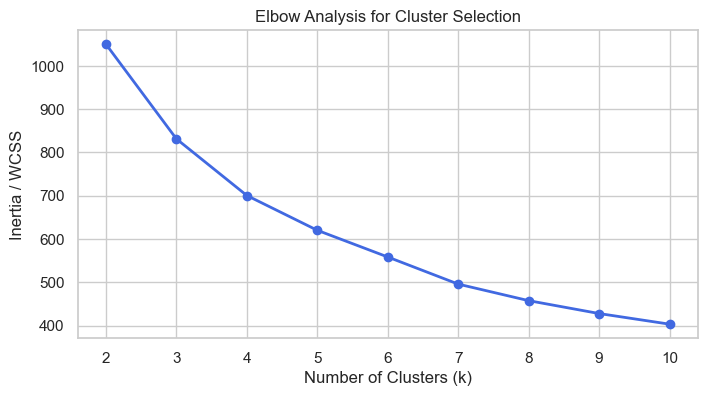

--> K-Means Silhouette Score (k=3): 0.2833

DBSCAN cluster counts (note: -1 corresponds to noise/outliers):
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


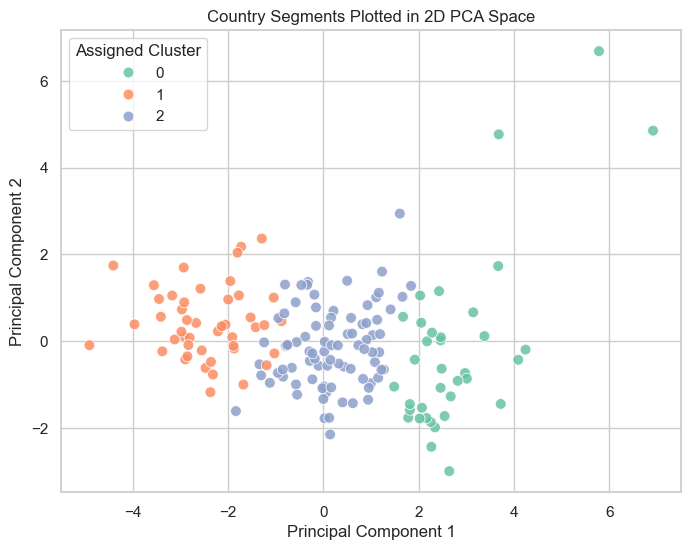


--- Mean values per K-Means cluster ---
                child_mort    income      gdpp  health
kmeans_cluster                                        
0                     5.00  45672.22  42494.44    8.81
1                    92.96   3942.40   1922.38    6.39
2                    21.93  12305.60   6486.45    6.20


In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')

# 1. Load & Clean the Dataset
df = pd.read_csv('resources/Country-data.csv')

# Clean up column names right away (lower casing and stripping trailing spaces)
df.columns = [col.strip().lower() for col in df.columns]
df = df.drop_duplicates()

num_features = [col for col in df.columns if col != 'country']

for col in num_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"Data ready. Matrix shape is: {df.shape}")

# 2. Scaling
# Standardize features since distance metrics are sensitive to scales (e.g., GDP vs Inflation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_features])

# 3. K-Means Elbow Optimization
wcss = [] 
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)


plt.figure(figsize=(8, 4))
plt.plot(list(k_range), wcss, marker='o', color='royalblue', linewidth=2)
plt.title('Elbow Analysis for Cluster Selection')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / WCSS')
plt.xticks(list(k_range))
plt.show()

# 4. Modeling: K-Means & DBSCAN Benchmark
# The elbow plot suggests an inflection point around 3 clusters
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_model.fit_predict(X_scaled)

# Quick validation check using Silhouette metrics
score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"--> K-Means Silhouette Score (k={optimal_k}): {score:.4f}")

# Running DBSCAN as a density-based comparison 
dbscan_model = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan_model.fit_predict(X_scaled)

print("\nDBSCAN cluster counts (note: -1 corresponds to noise/outliers):")
print(df['dbscan_cluster'].value_counts().sort_index())

# 5. PCA Projection & Plotting
# Smash features down to 2 dimensions for simple scatter visualization
pca_reducer = PCA(n_components=2, random_state=42)
pca_coords = pca_reducer.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'Cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    palette='Set2', 
    s=60, 
    alpha=0.85
)
plt.title('Country Segments Plotted in 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Assigned Cluster')
plt.show()

# Print out data-driven cluster profiles to wrap up
print("\n--- Mean values per K-Means cluster ---")
summary_metrics = ['child_mort', 'income', 'gdpp', 'health']
print(df.groupby('kmeans_cluster')[summary_metrics].mean().round(2))